In [1]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
import matplotlib.cm as cm


In [2]:
df = pd.read_csv("../data/20220524_q16f_full_mm.csv", header=0)

In [3]:
df.head()

,Cycle Nr.,Time [s],Temp. [°C],K1,K2,K3,K4,K5,K6,K7,...,M7,M8,M9,M10,M11,M12,M13,M14,M15,M16
0,1,0.000,28.9,4611,4401,3121,3017,2472,2458,2255,...,2492,2251,2166,2079,1960,2010,2008,1948,1953,1933
1,2,31.750,29.1,4718,4248,2971,2933,2392,2442,2221,...,2513,2247,2208,2045,1952,1994,1975,1939,1926,1947
2,3,63.000,29.0,4543,4185,2984,2912,2365,2419,2210,...,2505,2206,2188,2009,1928,2015,1918,1889,1896,1960
3,4,94.261,29.0,4487,4160,2974,2886,2335,2394,2217,...,2499,2216,2145,2041,1907,1992,1913,1923,1854,1934
4,5,125.521,29.0,4520,4173,3013,2887,2347,2423,2213,...,2510,2256,2148,2021,1973,2000,1921,1938,1924,1957


In [4]:
times = np.tile(df["Time [s]"], (16,1))

In [7]:
times

array([[    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       ...,
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305],
       [    0.   ,    65.403,   130.315, ..., 14215.491, 14280.397,
        14345.305]])

In [5]:
time_arr = times[0]

## MM Functions

In [6]:
def divide_chunks(l, n):
    n = math.ceil(len(l) / float(n))
    for i in range(0, len(l), n):
        yield l[i:i + n]

In [7]:
def compute_initial_reaction_slope(time_arr: np.array, 
                                   signal_arr: np.array,
                                  min_included_percent: int = 5): 
    
    perc_concs = list(divide_chunks(signal_arr, 100))
    perc_times = list(divide_chunks(time_arr, 100))
 
    scores = []
    slopes = [] 
    intercepts = []
    for i in range(len(perc_times), min_included_percent, -1):
        curr_times = [item for sublist in perc_times[:i] for item in sublist]
        curr_concs = [item for sublist in perc_concs[:i] for item in sublist]
        reg = LinearRegression().fit(np.array(curr_times).reshape(-1,1), curr_concs)
        curr_score = reg.score(np.array(curr_times).reshape(-1,1), curr_concs)
        scores.append(curr_score)
        slopes.append(reg.coef_)
        intercepts.append(reg.intercept_)
    max_r2_idx = np.argmax(scores)
    return slopes[max_r2_idx], intercepts[max_r2_idx], scores[max_r2_idx]

In [8]:
sub_concs = [1000, 500, 250, 125, 62.5, 31.25, 15.625, 7.8125]

In [27]:
def get_all_initial_slopes(time_arr: np.array, kinetic_data: np.array, substrate_concs: [int], title: str, fig_size: (int, int) = (10,10)):
    
    rep_1_arr = kinetic_data[0::2]
    rep_2_arr = kinetic_data[1::2]
    
    rep_1_slopes = []
    rep_2_slopes = []

    fig = plt.figure(figsize=fig_size) 
    for data, sub_conc in zip(rep_1_arr, sub_concs):
        slope, intercept, score = compute_initial_reaction_slope(time_arr, data)
        rep_1_slopes.append(slope)
        plt.scatter(time_arr, data)
        x = np.linspace(min(time_arr), max(time_arr), 1000)
        plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    plt.title(f"{title} Replicate 1")
    plt.xlabel("Time (seconds)")
    plt.ylabel("µM")
    plt.legend() 
    
    fig = plt.figure(figsize=fig_size) 
    for data, sub_conc in zip(rep_2_arr, sub_concs):
        slope, intercept, score = compute_initial_reaction_slope(time_arr, data)
        plt.scatter(time_arr, data)
        rep_2_slopes.append(slope)
        x = np.linspace(min(time_arr), max(time_arr), 1000)
        plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    plt.title(f"{title} Replicate 2")
    plt.xlabel("Time (seconds)")
    plt.ylabel("µM")
    plt.legend() 
    plt.show()
    return rep_1_slopes, rep_2_slopes

In [23]:
def mm_model(x, v_max, Km):
    return v_max * x / (x + Km)

In [22]:
def fit_and_plot_micheaelis_menten(rep_1_slopes: np.array, rep_2_slopes: np.array, sub_concs: [int], e_conc: float, title: str, background_rates: np.array = None):
    avg_slopes = np.mean([rep_1_slopes, rep_2_slopes], axis=0)
    if background_rates is not None:
        avg_slopes -= background_rates
    errs = np.std([rep_1_slopes, rep_2_slopes], axis=0) 
    params, _ = curve_fit(mm_model, sub_concs, np.concatenate(avg_slopes))
    
    plt.figure(figsize=(10,6))

    plt.scatter(sub_concs, avg_slopes/e_conc)
    plt.errorbar(sub_concs, np.concatenate(avg_slopes/e_conc), yerr=(errs/e_conc).T, fmt="o", capsize=5)
    x = np.linspace(0, 1000, 1000)
    plt.plot(x, mm_model(x, params[0], params[1]) / e_conc)
    plt.xlabel("[S] (µM)")
    plt.ylabel("v ($s^{-1}$)")
    plt.title(title + " kinetics: $k_{cat}$ = " +f"{params[0] / e_conc:.0f}" + " $s^{-1}$ " + f"  $K_m$ = {params[1]:.0f} µM")

# Q16f

In [31]:
e_conc = .789 * (1/50)

In [10]:
df.head()

,Cycle Nr.,Time [s],Temp. [°C],K1,K2,K3,K4,K5,K6,K7,...,M7,M8,M9,M10,M11,M12,M13,M14,M15,M16
0,1,0.000,28.9,4611,4401,3121,3017,2472,2458,2255,...,2492,2251,2166,2079,1960,2010,2008,1948,1953,1933
1,2,31.750,29.1,4718,4248,2971,2933,2392,2442,2221,...,2513,2247,2208,2045,1952,1994,1975,1939,1926,1947
2,3,63.000,29.0,4543,4185,2984,2912,2365,2419,2210,...,2505,2206,2188,2009,1928,2015,1918,1889,1896,1960
3,4,94.261,29.0,4487,4160,2974,2886,2335,2394,2217,...,2499,2216,2145,2041,1907,1992,1913,1923,1854,1934
4,5,125.521,29.0,4520,4173,3013,2887,2347,2423,2213,...,2510,2256,2148,2021,1973,2000,1921,1938,1924,1957


In [15]:
gs_q16f_df = df.iloc[:, 19:35]
gs_q16f_arr = np.array(gs_q16f_df).T

In [16]:
gs_q16f_conc = .789 * (1/50)

# Computing Background Rates

In [18]:
q16f_no_enz_df = df.iloc[:, 35:51]
q16f_no_enz_arr = np.array(q16f_no_enz_df).T

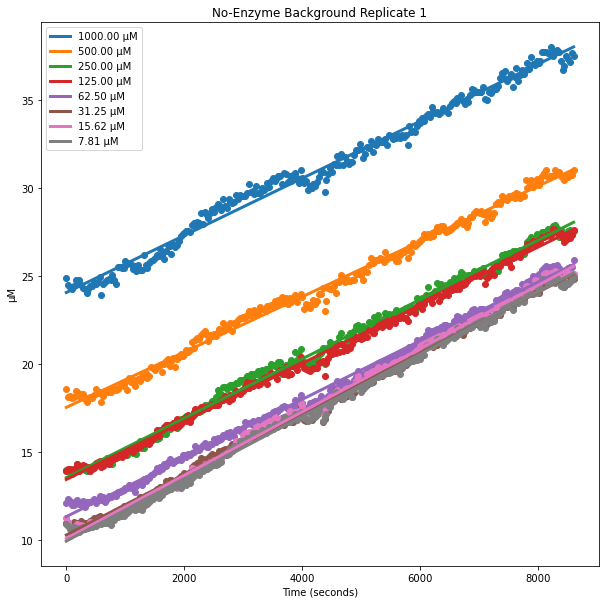

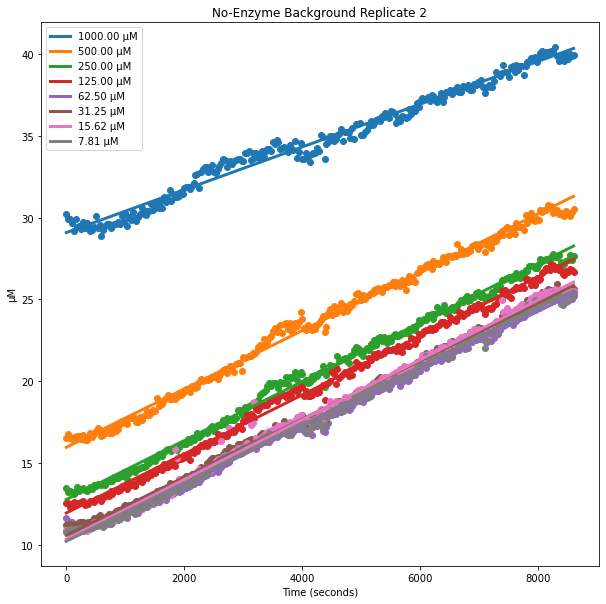

In [19]:
q16f_no_enz_r1_slopes, q16f_no_enz_r2_slopes = get_all_initial_slopes(time_arr, q16f_no_enz_arr / 179, sub_concs, "No-Enzyme Background")

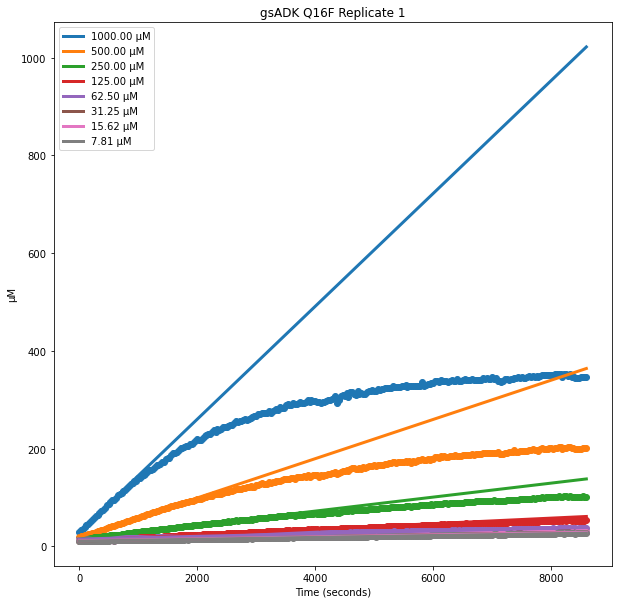

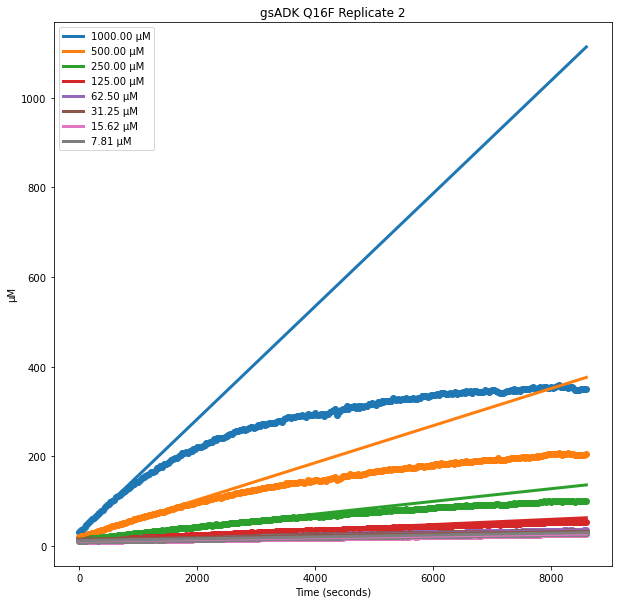

In [20]:
gsADK_q16f_r1_slopes, gsADK_q16f_r2_slopes = get_all_initial_slopes(time_arr, gs_q16f_arr / 179, sub_concs, "gsADK Q16F", fig_size=)

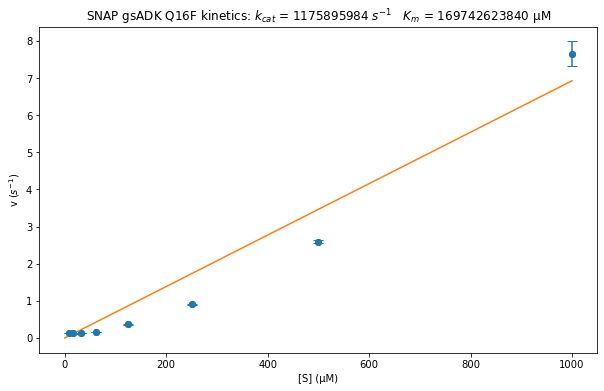

In [24]:
fit_and_plot_micheaelis_menten(gsADK_q16f_r1_slopes, gsADK_q16f_r2_slopes, sub_concs, 
                               gs_q16f_conc, "SNAP gsADK Q16F", np.mean([q16f_no_enz_r1_slopes, q16f_no_enz_r2_slopes], axis=0))

# R88G

In [30]:
r88g_df = pd.read_csv("../data/20220525_R88G_full_mm.csv", header=0)

In [52]:
gs_r88g_df = r88g_df.iloc[:, 3:18]
gs_r88g_df["N16"] = gs_r88g_df["N15"]

gs_r88g_arr = np.array(gs_r88g_df).T

In [40]:
r88g_no_enz_df = r88g_df.iloc[:, 18:33]
r88g_no_enz_df["O16"] = r88g_no_enz_df["O15"]
r88g_no_enz_arr = np.array(r88g_no_enz_df).T

In [51]:
r88g_no_enz_arr.shape

(16, 994)

In [45]:
r88g_times = np.tile(r88g_df["Time [s]"], (16,1))

In [46]:
r88g_time_arr = r88g_times[0]

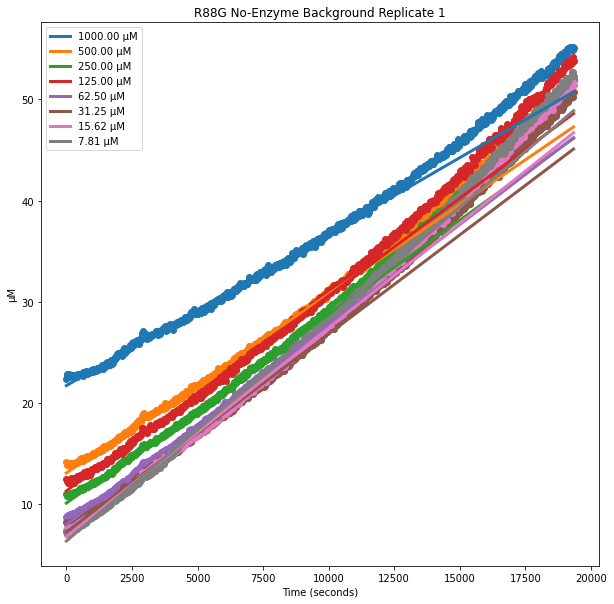

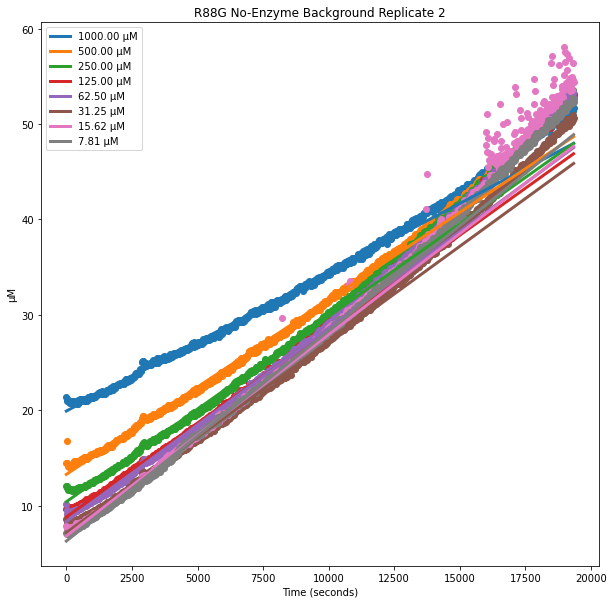

In [47]:
r88g_no_enz_r1_slopes, r88g_no_enz_r2_slopes = get_all_initial_slopes(r88g_time_arr, r88g_no_enz_arr / 179, sub_concs, "R88G No-Enzyme Background")

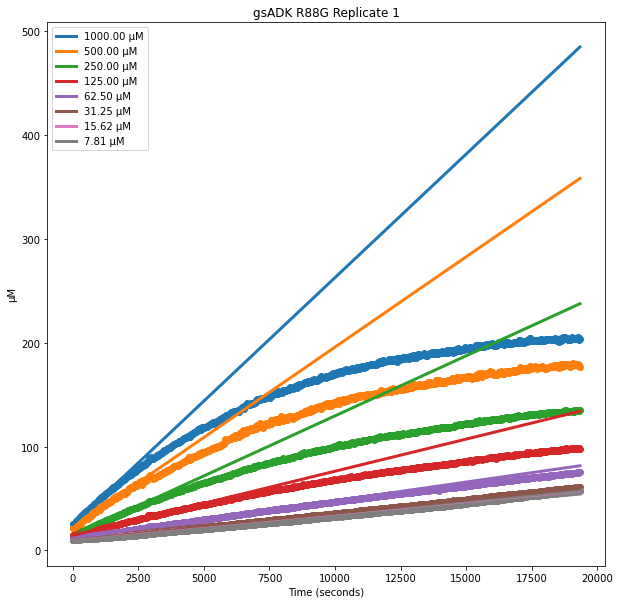

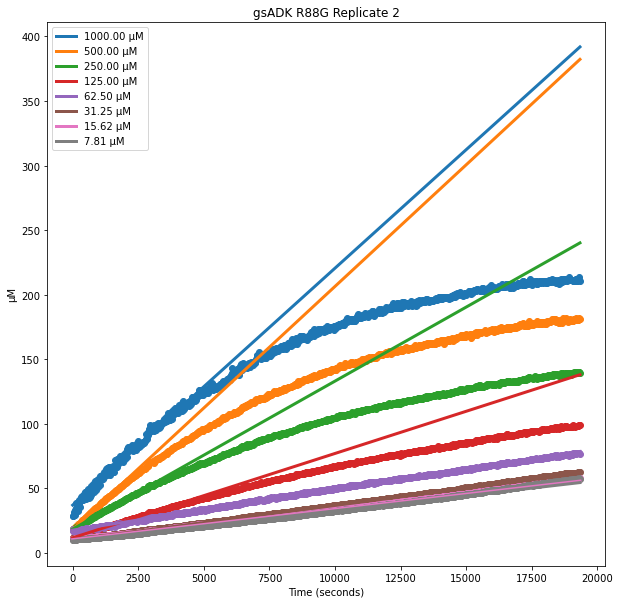

In [53]:
gsADK_r88g_r1_slopes, gsADK_r88g_r2_slopes = get_all_initial_slopes(r88g_time_arr, gs_r88g_arr / 179, sub_concs, "gsADK R88G")

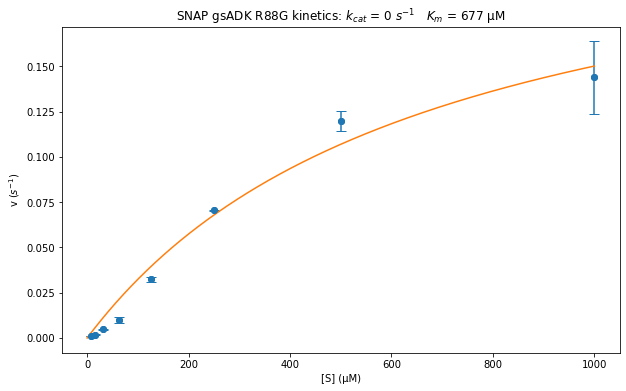

In [55]:
fit_and_plot_micheaelis_menten(gsADK_r88g_r1_slopes, gsADK_r88g_r2_slopes, sub_concs, .681 * (30/150), "SNAP gsADK R88G", np.mean([r88g_no_enz_r1_slopes, r88g_no_enz_r2_slopes], axis=0))

In [73]:
gs_r88g_df = df.iloc[:, 2:18]
gs_r88g_arr = np.array(gs_r88g_df).T

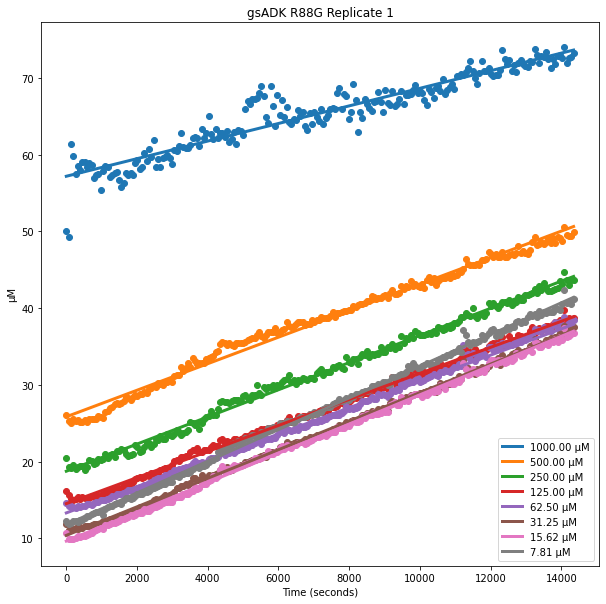

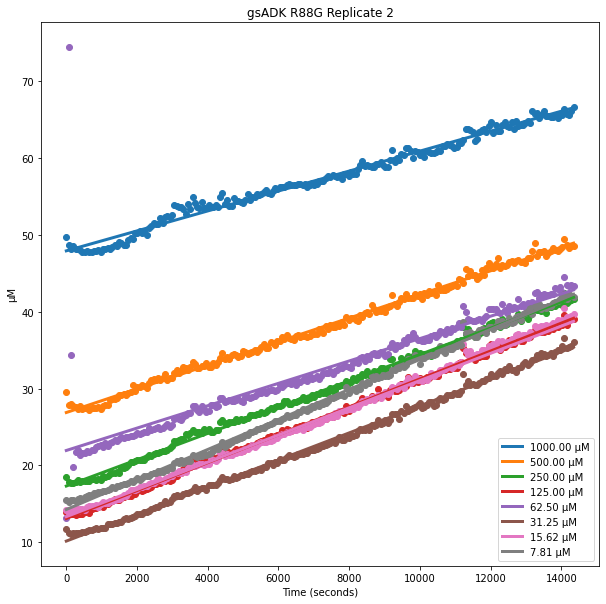

In [74]:
gsADK_r88g_r1_slopes, gsADK_r88g_r2_slopes = get_all_initial_slopes(time_arr, gs_r88g_arr / 179, sub_concs, "gsADK R88G")

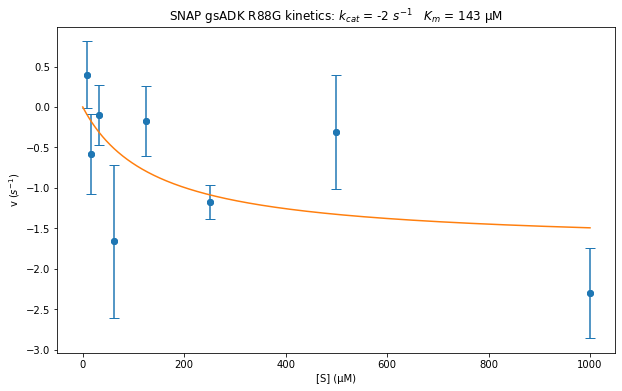

In [75]:
fit_and_plot_micheaelis_menten(gsADK_r88g_r1_slopes, gsADK_r88g_r2_slopes, sub_concs, .681 * 2e-4, "SNAP gsADK R88G", np.mean([no_enz_r1_slopes, no_enz_r2_slopes], axis=0))

In [100]:
def multi_mm_plots(samples: [(np.array, np.array, float, str)], sub_concs: [int], title: str, cmap_bound: (int, int) = (0,1), background_rates: np.array = None,):
    plt.figure(figsize=(10,10))
    cmap = cm.get_cmap('plasma')

    color_vals = np.linspace(cmap_bound[0], cmap_bound[1], len(samples))
    print(len(samples))
    for sample, color_val in zip(samples, color_vals):
        rep_1_slopes, rep_2_slopes, e_conc, label = sample
        avg_slopes = np.mean([rep_1_slopes, rep_2_slopes], axis=0)
        if background_rates is not None:
            avg_slopes -= background_rates
        errs = np.std([rep_1_slopes, rep_2_slopes], axis=0) 
        params, _ = curve_fit(mm_model, sub_concs, np.concatenate(avg_slopes))


        plt.scatter(sub_concs, avg_slopes/e_conc, color=cmap(color_val))
        plt.errorbar(sub_concs, np.concatenate(avg_slopes/e_conc), yerr=(errs/e_conc).T, fmt="o", capsize=5, color=cmap(color_val))
        x = np.linspace(0, 1000, 1000)
        k_cat = f"{params[0] / e_conc:.0f}"
        K_m = f"{params[1]:.0f}"
        prop_label = label + ": $k_{cat}$=" + k_cat + " $s^{-1}$ " + f"  $K_m$=" +  K_m + " µM"
        plt.plot(x, mm_model(x, params[0], params[1]) / e_conc, color=cmap(color_val), label=prop_label)
        plt.legend()
    plt.xlabel("[S] (µM)")
    plt.ylabel("v ($s^{-1}$)")
    plt.title(title)

3


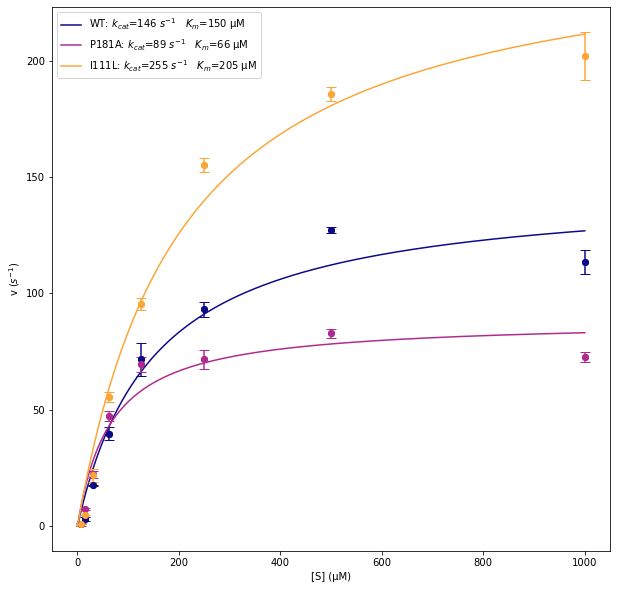

In [102]:
multi_mm_plots([(gsADK_wt_r1_slopes, gsADK_wt_r2_slopes, .652*2e-4,"WT"),
                (gsADK_p181a_r1_slopes, gsADK_p181a_r2_slopes, .885*2e-4, "P181A"),
                (gsADK_i111l_r1_slopes, gsADK_i111l_r2_slopes, .618*2e-4, "I111L")],
               sub_concs, "gsADK MM Kinetics", cmap_bound = (0,0.8), background_rates=np.mean([no_enz_r1_slopes, no_enz_r2_slopes], axis=0))